# Deep-LDA vs. $\phi$: WT-Metadynamics Comparison at Matched Protocol

**Benchmark of a machine-learned collective variable (Deep-LDA) against the natural
backbone dihedral $\phi$ as the biased coordinate in well-tempered metadynamics
(WT-MetaD), at a fixed bias protocol.**

For each collective variable (CV) a single 10 ns WT-MetaD run is performed with
`BIASFACTOR=6` and `SIGMA=0.025`, following the methodology of Bonati, Rizzi &
Parrinello [1] for the CV and of Barducci, Bussi & Parrinello [2] for well-tempered
metadynamics. For each run we report, in order:

1. the time evolution of the deposited Gaussian-kernel height (monitors convergence
   towards the well-tempered quasi-static regime);
2. the free-energy surface (FES) reconstructed every 100 deposited kernels, to
   visualize convergence of the bias potential;
3. the free-energy difference between the two metastable basins ($C7_{eq}$ and
   $C7_{ax}$), as a function of simulation time, obtained via Tiwary–Parrinello
   reweighting [3];
4. the statistical error on the reweighted FES estimated by block analysis [3,4],
   following the mlcolvar-native implementation of `compute_fes` (block averaging
   over independent trajectory chunks).

Basin membership is always assessed on $\phi$ (printed in every run irrespective of
which CV is biased), so that the two runs are directly comparable.

The notebook closes with two overlay plots comparing Deep-LDA and $\phi$ directly:
the basin free-energy-difference convergence, and the block-analysis error curves.

**Author:** Daniele — Dipartimento di Fisica, Università di Genova.


## 0. Setup

In [33]:

import os
import re
import math
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from mlcolvar.utils.io import load_dataframe
from mlcolvar.utils.fes import compute_fes

torch.set_float32_matmul_precision('high')


In [34]:

# ------------------------------- Configuration -------------------------------
BASE_DIR    = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR   = BASE_DIR / "input"
MD_IN_DIR   = INPUT_DIR / "md_inputs"
GMX_CMD     = "gmx_mpi"

# All outputs of this comparison live under data2/9_deeplda_vs_phi, as requested.
DATA_DIR = BASE_DIR / "data2"
OUT_DIR  = DATA_DIR / "9_deeplda_vs_phi"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Reuse of the Deep-LDA model and of the unbiased reference runs (state A/B) trained
# and produced in the earlier stages of the pipeline: adjust these two paths if your
# latest exported model / unbiased runs live elsewhere.
PREV_DATA_DIR   = BASE_DIR / "data2"
MODEL_SRC_DIR   = PREV_DATA_DIR / "1_meta-deeplda"          # contains model.ptc
UNBIASED_A_DIR  = PREV_DATA_DIR / "0_unbiased-sA"            # contains COLVAR (state A, C7eq)
UNBIASED_B_DIR  = PREV_DATA_DIR / "0_unbiased-sB"            # contains COLVAR (state B, C7ax)
SCRIPT_BLOCK_FES = BASE_DIR / "notebook" / "do_block_fes.py"  # PLUMED Masterclass block-analysis utility
                                                                # (same one used in 03_analysis.ipynb)

DESCRIPTORS = ("d_2_5,d_2_6,d_2_7,d_2_9,d_2_11,d_2_15,d_2_16,d_2_17,d_2_19,"
               "d_5_6,d_5_7,d_5_9,d_5_11,d_5_15,d_5_16,d_5_17,d_5_19,"
               "d_6_7,d_6_9,d_6_11,d_6_15,d_6_16,d_6_17,d_6_19,"
               "d_7_9,d_7_11,d_7_15,d_7_16,d_7_17,d_7_19,"
               "d_9_11,d_9_15,d_9_16,d_9_17,d_9_19,"
               "d_11_15,d_11_16,d_11_17,d_11_19,"
               "d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19")

# ------------------------------- Bias protocol (fixed as requested) -------------------------------
TEMP          = 300.0
KBT           = 2.494339          # kJ/mol @ 300 K
DT_PS         = 0.002             # 2 fs timestep
NUM_STEPS_10NS = 5_000_000        # 10 ns @ dt = 2 fs
STRIDE_BIAS   = 100                # COLVAR print stride (steps) -> 0.2 ps/frame
PACE          = 500                # 1 kernel deposited every 1 ps (inherited from the
                                    # established protocol; not specified by the request)
HEIGHT        = 1.25               # kJ/mol, initial Gaussian height (same rationale as above)
BIASFACTOR    = 6.0                # requested
SIGMA         = 0.025              # requested, common to both CVs

KERNELS_PER_FES_SNAPSHOT = 100     # "every 100 Gaussian kernels deposited"
FRAME_DT_NS   = STRIDE_BIAS * DT_PS / 1000.0   # time between two consecutive COLVAR rows [ns]

os.chdir(BASE_DIR)
print("Output directory:", OUT_DIR)
print(f"Frame spacing in COLVAR: {FRAME_DT_NS*1000:.3f} ps ({NUM_STEPS_10NS*DT_PS/1000:.1f} ns total, "
      f"{NUM_STEPS_10NS//STRIDE_BIAS} frames/run, {NUM_STEPS_10NS//PACE} kernels/run)")


Output directory: /home/dani/wslcoding/MCFM/ML-CV/data2/9_deeplda_vs_phi
Frame spacing in COLVAR: 0.200 ps (10.0 ns total, 50000 frames/run, 10000 kernels/run)


### Helper functions

In [35]:

def execute(command, folder, background=False):
    """Run a shell command in `folder`, printing stderr on failure."""
    cmd = subprocess.run(command, cwd=folder, shell=True, capture_output=True, text=True, close_fds=background)
    if cmd.returncode == 0:
        print(f'Completed: {command}')
    else:
        print(cmd.stderr)
    return cmd


def load_hills(path):
    """Load a PLUMED HILLS file, parsing column names from the '#! FIELDS' header
    instead of assuming a fixed column order."""
    with open(path) as f:
        header = f.readline()
    assert header.startswith("#! FIELDS"), f"Unexpected HILLS header in {path}"
    fields = header.split()[3:]
    hills = pd.read_csv(path, sep=r'\s+', comment='#', names=fields)
    return hills


def rbias_weights(colvar, kbt=KBT):
    """Tiwary-Parrinello reweighting for WT-MetaD: w_i = exp((V(s_i,t_i) - c(t_i)) / kT).
    Requires the 'metad.bias' and 'metad.rct' columns (CALC_RCT)."""
    rbias = colvar['metad.bias'].values - colvar['metad.rct'].values
    return np.exp(rbias / kbt)


def deltaF_time_evolution(colvar, weights, basin_A, basin_B, n_slices=60, cv_col="phi"):
    """Cumulative-trajectory estimate of Delta F = F_B - F_A as a function of time,
    from the (growing) reweighted population of each basin."""
    time_ns = colvar['time'].values / 1000.0
    cv = colvar[cv_col].values
    slice_idx = np.linspace(len(cv) // n_slices, len(cv), n_slices, dtype=int)

    t_out, dF_out = [], []
    for idx in slice_idx:
        cv_s, w_s = cv[:idx], weights[:idx]
        mask_A = (cv_s >= basin_A[0]) & (cv_s <= basin_A[1])
        mask_B = (cv_s >= basin_B[0]) & (cv_s <= basin_B[1])
        P_A, P_B = w_s[mask_A].sum(), w_s[mask_B].sum()
        if P_A > 0 and P_B > 0:
            t_out.append(time_ns[idx - 1])
            dF_out.append(-KBT * math.log(P_B / P_A))
    return np.array(t_out), np.array(dF_out)


def block_analysis_error(cv, weights, bounds, block_sizes, bandwidth=0.02,
                          num_samples=200, fes_cutoff=30.0):
    """mlcolvar-native block analysis: for each candidate block size (in frames),
    split the trajectory into blocks and use compute_fes(..., blocks=n_blocks) to
    obtain the block-averaged standard error on the FES. Returns the block sizes (in
    ns) actually used together with the corresponding average error over the
    well-sampled region (FES < fes_cutoff), i.e. the classical block-analysis curve
    whose plateau at large block size gives the true statistical uncertainty."""
    block_sizes_ns, errors = [], []
    n_frames = len(cv)
    for b in block_sizes:
        n_blocks = n_frames // b
        if n_blocks < 4:
            continue
        fes, grid, _, error = compute_fes(cv[: n_blocks * b], weights=weights[: n_blocks * b],
                                           kbt=KBT, bounds=bounds, bandwidth=bandwidth,
                                           num_samples=num_samples, blocks=n_blocks)
        mask = np.isfinite(fes) & (fes < fes_cutoff)
        if not np.any(mask):
            continue
        block_sizes_ns.append(b * FRAME_DT_NS)
        errors.append(float(np.nanmean(error[mask])))
    return np.array(block_sizes_ns), np.array(errors)


def fes_every_n_kernels(hills_path, out_prefix, n_kernels=KERNELS_PER_FES_SNAPSHOT):
    """Reconstruct F(s) = -V(s, t) directly from the deposited hills (bias
    inversion via `plumed sum_hills`), dumping a snapshot every `n_kernels`
    deposited Gaussians. Valid because well-tempered MetaD bias inversion recovers
    F(s)/gamma up to a known rescaling; here we report -V(s,t) itself, i.e. the
    growing (not yet rescaled) bias, which is the natural per-kernel diagnostic.

    Note: with --stride, PLUMED treats --outfile as a bare *prefix* and appends
    '<index>.dat' directly (e.g. --outfile fes_ -> fes_0.dat, fes_1.dat, ...),
    NOT '<outfile>.<index>'. See sum_hills documentation/source (SumHills.cpp)."""
    out_dir = Path(out_prefix).parent
    prefix = Path(out_prefix).name + "_"   # e.g. "fes_deeplda_" -> fes_deeplda_0.dat, ...
    cmd = f"plumed sum_hills --hills {hills_path} --stride {n_kernels} --mintozero --outfile {prefix}"

    cmd_result = subprocess.run(cmd, cwd=out_dir, shell=True, capture_output=True, text=True)
    if cmd_result.returncode != 0:
        raise RuntimeError(
            f"'plumed sum_hills' failed (return code {cmd_result.returncode}).\n"
            f"Command: {cmd}\nWorking directory: {out_dir}\nStderr:\n{cmd_result.stderr}"
        )
    print(f"Completed: {cmd}")

    pattern = re.compile(rf"^{re.escape(prefix)}(\d+)\.dat$")
    stride_files = []
    for f in out_dir.iterdir():
        m = pattern.match(f.name)
        if m:
            stride_files.append((int(m.group(1)), f))
    stride_files.sort(key=lambda x: x[0])

    if not stride_files:
        existing = sorted(p.name for p in out_dir.iterdir() if prefix.rstrip('_') in p.name)
        raise RuntimeError(
            f"No stride FES files matching '{prefix}<N>.dat' found in {out_dir}.\n"
            f"Files found with a similar name: {existing}\n"
            "Check that the 'plumed sum_hills' command above completed without errors "
            "and that HILLS actually contains more than one deposited kernel."
        )

    snapshots = []
    for idx, f in stride_files:
        df = load_dataframe(str(f))
        snapshots.append(((idx + 1) * n_kernels, df))   # index 0 -> first n_kernels processed
    return snapshots


### Deep-LDA model and basin reference

We reuse the Deep-LDA model already trained and exported to TorchScript, and the
two unbiased reference trajectories used to characterize the metastable states
$C7_{eq}$ (state A) and $C7_{ax}$ (state B). Basin ranges are defined on $\phi$
(1st/99th percentile of each unbiased trajectory), so that basin membership can be
assessed consistently on **both** runs below, whichever CV is biased.

In [36]:

assert (MODEL_SRC_DIR / "model.ptc").exists(), \
    f"Deep-LDA model not found at {MODEL_SRC_DIR / 'model.ptc'} -- update MODEL_SRC_DIR."

dataA = load_dataframe(f"{UNBIASED_A_DIR}/COLVAR")
dataB = load_dataframe(f"{UNBIASED_B_DIR}/COLVAR")

PHI_BASIN_A = (float(dataA["phi"].quantile(0.01)), float(dataA["phi"].quantile(0.99)))
PHI_BASIN_B = (float(dataB["phi"].quantile(0.01)), float(dataB["phi"].quantile(0.99)))
print(f"Basin A (C7eq) in phi: {PHI_BASIN_A}")
print(f"Basin B (C7ax) in phi: {PHI_BASIN_B}")


Basin A (C7eq) in phi: (-2.89923, -1.03365)
Basin B (C7ax) in phi: (0.699344, 1.34587)


## 1. Deep-LDA: 10 ns WT-MetaD run

In [37]:

folder_deeplda = OUT_DIR / "deeplda_wtmetad"
folder_deeplda.mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_deeplda)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_deeplda)
execute(f"cp {MODEL_SRC_DIR}/model.ptc .", folder_deeplda)


Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/data2/1_meta-deeplda/model.ptc .


CompletedProcess(args='cp /home/dani/wslcoding/MCFM/ML-CV/data2/1_meta-deeplda/model.ptc .', returncode=0, stdout='', stderr='')

In [38]:

plumed_deeplda = f"""# vim:ft=plumed
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
ene: ENERGY

INCLUDE FILE={INPUT_DIR}/plumed-distances.dat
deep: PYTORCH_MODEL FILE=model.ptc ARG={DESCRIPTORS}

metad: METAD ARG=deep.node-0 ...
   PACE={PACE} HEIGHT={HEIGHT} BIASFACTOR={BIASFACTOR} TEMP={TEMP}
   SIGMA={SIGMA}
   FILE=HILLS GRID_MIN=-2 GRID_MAX=2 GRID_BIN=750 CALC_RCT
...

PRINT FMT=%g STRIDE={STRIDE_BIAS} FILE=COLVAR ARG=phi,psi,deep.node-0,metad.bias,metad.rct
ENDPLUMED
"""

with open(folder_deeplda / "plumed.dat", "w") as f:
    f.write(plumed_deeplda)

print(f"cd {folder_deeplda}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on "
      f"-nsteps {NUM_STEPS_10NS} -v")


cd /home/dani/wslcoding/MCFM/ML-CV/data2/9_deeplda_vs_phi/deeplda_wtmetad
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on -nsteps 5000000 -v


**Run the command printed above in WSL (≈10 ns, expect a few hours on the
RTX 3050 laptop GPU at `-ntomp 1`), then continue with the analysis below.**

> Restart tip: rerun the same `mdrun` command with `-cpi alanine.cpt` appended, if
> the run needs to be resumed from a checkpoint.

In [39]:

colvar_deeplda = load_dataframe(f"{folder_deeplda}/COLVAR")
hills_deeplda  = load_hills(folder_deeplda / "HILLS")
weights_deeplda = rbias_weights(colvar_deeplda)

print(f"Deep-LDA run: {len(colvar_deeplda)} COLVAR frames, {len(hills_deeplda)} deposited kernels")
colvar_deeplda.head()


Deep-LDA run: 50001 COLVAR frames, 10000 deposited kernels


,time,phi,psi,deep.node-0,metad.bias,metad.rct,walker
0,0.0,-2.36867,2.64432,-1.14207,0.0,0.0,0
1,0.2,-2.01898,2.09469,-1.13165,0.0,0.0,0
2,0.4,-1.13140,2.51985,-1.14193,0.0,0.0,0
3,0.6,-1.64722,2.11313,-1.12397,0.0,0.0,0
4,0.8,-1.69177,2.11844,-1.11413,0.0,0.0,0


### 1.1 Time evolution of the Gaussian height

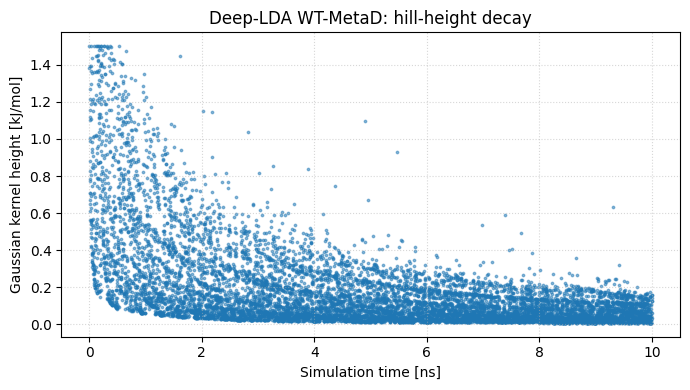

In [41]:

fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
ax.scatter(hills_deeplda.index / 1000.0, hills_deeplda["height"], s=3, alpha=0.5, color="tab:blue")
ax.set_xlabel("Simulation time [ns]")
ax.set_ylabel(r"Gaussian kernel height [kJ/mol]")
ax.set_title("Deep-LDA WT-MetaD: hill-height decay")
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


### 1.2 FES as a function of Deep-LDA, every 100 deposited kernels

Completed: plumed sum_hills --hills /home/dani/wslcoding/MCFM/ML-CV/data2/9_deeplda_vs_phi/deeplda_wtmetad/HILLS --stride 100 --mintozero --outfile fes_deeplda_


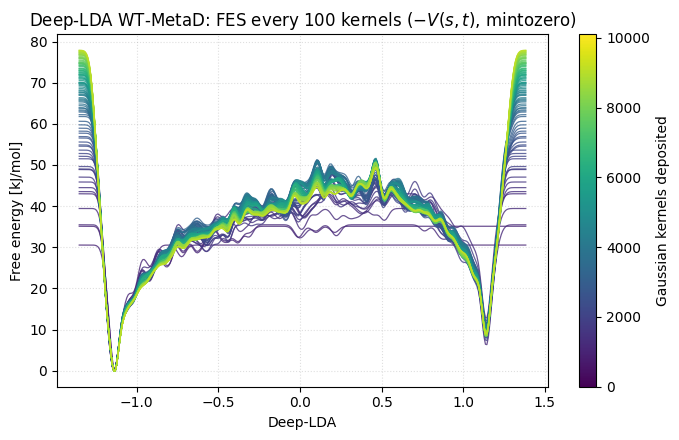

In [42]:

fes_snapshots_deeplda = fes_every_n_kernels(
    folder_deeplda / "HILLS", folder_deeplda / "fes_deeplda", n_kernels=KERNELS_PER_FES_SNAPSHOT
)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=100)
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(fes_snapshots_deeplda)))
for color, (n_kernels_dep, df) in zip(cmap, fes_snapshots_deeplda):
    ax.plot(df["deep.node-0"], df["file.free"], color=color, lw=0.9, alpha=0.8)

sm = plt.cm.ScalarMappable(cmap="viridis",
                            norm=plt.Normalize(0, fes_snapshots_deeplda[-1][0]))
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Gaussian kernels deposited")

ax.set_xlabel("Deep-LDA")
ax.set_ylabel("Free energy [kJ/mol]")
ax.set_title(r"Deep-LDA WT-MetaD: FES every 100 kernels ($-V(s,t)$, mintozero)")
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


### 1.3 Free-energy difference between basins

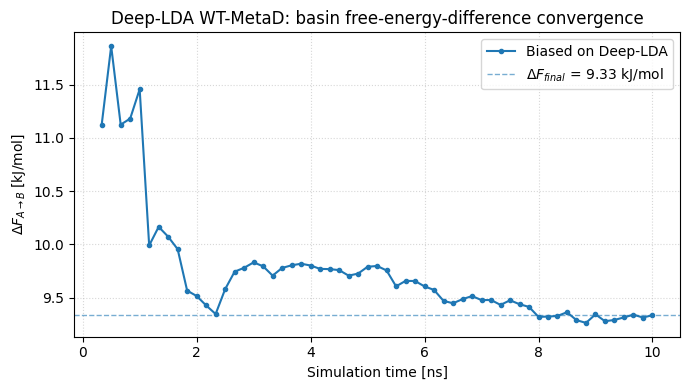

Deep-LDA: Delta F (C7eq -> C7ax) = 9.33 kJ/mol (final estimate)


In [43]:

t_deeplda, dF_deeplda = deltaF_time_evolution(colvar_deeplda, weights_deeplda, PHI_BASIN_A, PHI_BASIN_B)

fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
ax.plot(t_deeplda, dF_deeplda, 'o-', ms=3, color="tab:blue", label="Biased on Deep-LDA")
ax.axhline(dF_deeplda[-1], color="tab:blue", ls="--", lw=1, alpha=0.6,
           label=fr"$\Delta F_{{final}}$ = {dF_deeplda[-1]:.2f} kJ/mol")
ax.set_xlabel("Simulation time [ns]")
ax.set_ylabel(r"$\Delta F_{A \to B}$ [kJ/mol]")
ax.set_title("Deep-LDA WT-MetaD: basin free-energy-difference convergence")
ax.legend(frameon=True)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Deep-LDA: Delta F (C7eq -> C7ax) = {dF_deeplda[-1]:.2f} kJ/mol (final estimate)")


### 1.4 Error on the free energy via block analysis

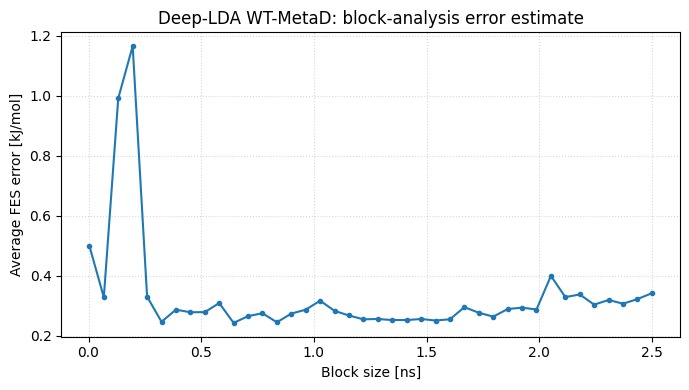

Deep-LDA: plateau error estimate = 0.342 kJ/mol


In [44]:

BOUNDS_DEEPLDA = (float(colvar_deeplda["deep.node-0"].min()) - 0.05,
                  float(colvar_deeplda["deep.node-0"].max()) + 0.05)
BLOCK_SIZES = np.unique(np.linspace(20, len(colvar_deeplda) // 4, 40, dtype=int))

blocks_ns_deeplda, err_deeplda = block_analysis_error(
    colvar_deeplda["deep.node-0"].values, weights_deeplda, BOUNDS_DEEPLDA, BLOCK_SIZES
)

fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
ax.plot(blocks_ns_deeplda, err_deeplda, 'o-', ms=3, color="tab:blue")
ax.set_xlabel("Block size [ns]")
ax.set_ylabel("Average FES error [kJ/mol]")
ax.set_title("Deep-LDA WT-MetaD: block-analysis error estimate")
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Deep-LDA: plateau error estimate = {err_deeplda[-1]:.3f} kJ/mol")


## 2. $\phi$: 10 ns WT-MetaD run

In [45]:

folder_phi = OUT_DIR / "phi_wtmetad"
folder_phi.mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_phi)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_phi)


Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .


CompletedProcess(args='cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .', returncode=0, stdout='', stderr='')

In [46]:

plumed_phi = f"""# vim:ft=plumed
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
ene: ENERGY

metad: METAD ARG=phi ...
   PACE={PACE} HEIGHT={HEIGHT} BIASFACTOR={BIASFACTOR} TEMP={TEMP}
   SIGMA={SIGMA}
   FILE=HILLS GRID_MIN=-pi GRID_MAX=pi GRID_BIN=750 CALC_RCT
...

PRINT FMT=%g STRIDE={STRIDE_BIAS} FILE=COLVAR ARG=phi,psi,metad.bias,metad.rct
ENDPLUMED
"""

with open(folder_phi / "plumed.dat", "w") as f:
    f.write(plumed_phi)

print(f"cd {folder_phi}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on "
      f"-nsteps {NUM_STEPS_10NS} -v")


cd /home/dani/wslcoding/MCFM/ML-CV/data2/9_deeplda_vs_phi/phi_wtmetad
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on -nsteps 5000000 -v


**Run the command printed above in WSL, then continue with the analysis
below.** Same protocol as the Deep-LDA run (`BIASFACTOR=6`, `SIGMA=0.025`, 10 ns),
so that the two runs are directly comparable.

In [47]:

colvar_phi = load_dataframe(f"{folder_phi}/COLVAR")
hills_phi  = load_hills(folder_phi / "HILLS")
weights_phi = rbias_weights(colvar_phi)

print(f"phi run: {len(colvar_phi)} COLVAR frames, {len(hills_phi)} deposited kernels")
colvar_phi.head()


phi run: 50001 COLVAR frames, 10000 deposited kernels


,time,phi,psi,metad.bias,metad.rct,walker
0,0.0,-2.36867,2.64432,0.0,0.0,0
1,0.2,-2.01898,2.09469,0.0,0.0,0
2,0.4,-1.13140,2.51985,0.0,0.0,0
3,0.6,-1.64722,2.11313,0.0,0.0,0
4,0.8,-1.69177,2.11844,0.0,0.0,0


### 2.1 Time evolution of the Gaussian height

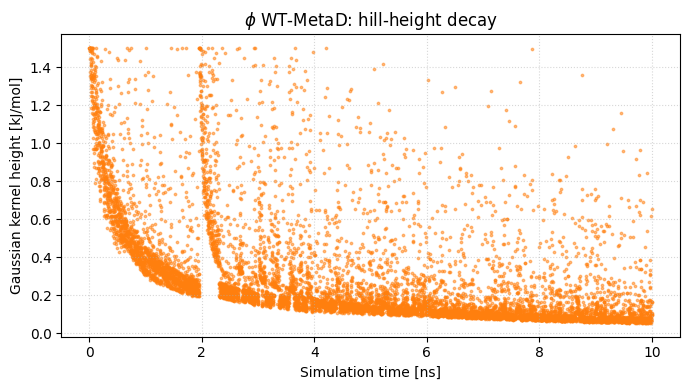

In [49]:

fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
ax.scatter(hills_phi.index / 1000.0, hills_phi["height"], s=3, alpha=0.5, color="tab:orange")
ax.set_xlabel("Simulation time [ns]")
ax.set_ylabel(r"Gaussian kernel height [kJ/mol]")
ax.set_title(r"$\phi$ WT-MetaD: hill-height decay")
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


### 2.2 FES as a function of $\phi$, every 100 deposited kernels

Completed: plumed sum_hills --hills /home/dani/wslcoding/MCFM/ML-CV/data2/9_deeplda_vs_phi/phi_wtmetad/HILLS --stride 100 --mintozero --outfile fes_phi_


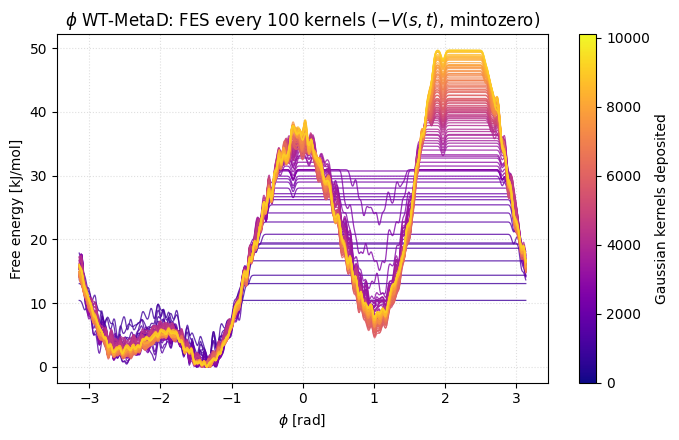

In [50]:

fes_snapshots_phi = fes_every_n_kernels(
    folder_phi / "HILLS", folder_phi / "fes_phi", n_kernels=KERNELS_PER_FES_SNAPSHOT
)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=100)
cmap = plt.cm.plasma(np.linspace(0.1, 0.9, len(fes_snapshots_phi)))
for color, (n_kernels_dep, df) in zip(cmap, fes_snapshots_phi):
    ax.plot(df["phi"], df["file.free"], color=color, lw=0.9, alpha=0.8)

sm = plt.cm.ScalarMappable(cmap="plasma",
                            norm=plt.Normalize(0, fes_snapshots_phi[-1][0]))
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Gaussian kernels deposited")

ax.set_xlabel(r"$\phi$ [rad]")
ax.set_ylabel("Free energy [kJ/mol]")
ax.set_title(r"$\phi$ WT-MetaD: FES every 100 kernels ($-V(s,t)$, mintozero)")
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


### 2.3 Free-energy difference between basins

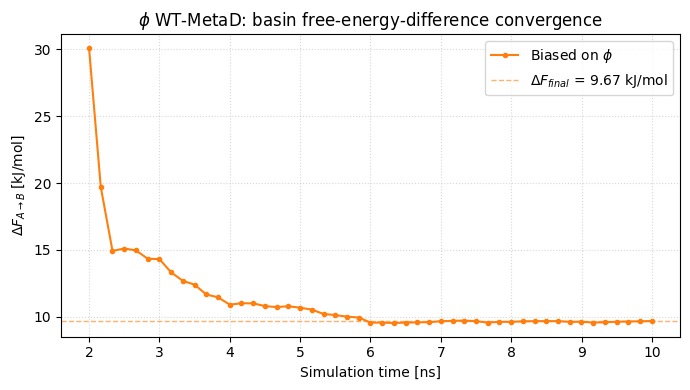

phi: Delta F (C7eq -> C7ax) = 9.67 kJ/mol (final estimate)


In [51]:

t_phi, dF_phi = deltaF_time_evolution(colvar_phi, weights_phi, PHI_BASIN_A, PHI_BASIN_B)

fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
ax.plot(t_phi, dF_phi, 'o-', ms=3, color="tab:orange", label=r"Biased on $\phi$")
ax.axhline(dF_phi[-1], color="tab:orange", ls="--", lw=1, alpha=0.6,
           label=fr"$\Delta F_{{final}}$ = {dF_phi[-1]:.2f} kJ/mol")
ax.set_xlabel("Simulation time [ns]")
ax.set_ylabel(r"$\Delta F_{A \to B}$ [kJ/mol]")
ax.set_title(r"$\phi$ WT-MetaD: basin free-energy-difference convergence")
ax.legend(frameon=True)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"phi: Delta F (C7eq -> C7ax) = {dF_phi[-1]:.2f} kJ/mol (final estimate)")


### 2.4 Error on the free energy via block analysis

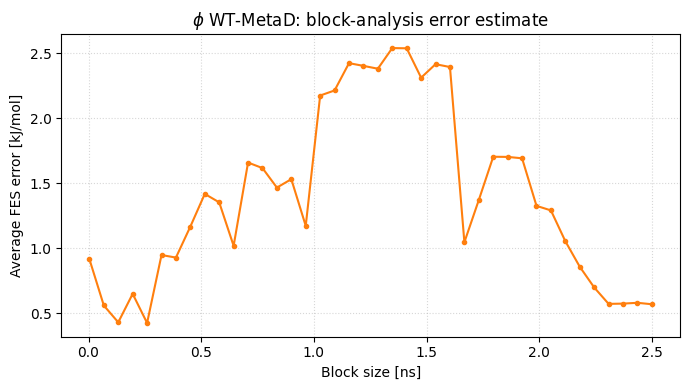

phi: plateau error estimate = 0.567 kJ/mol


In [52]:

BOUNDS_PHI = (-np.pi - 0.05, np.pi + 0.05)

blocks_ns_phi, err_phi = block_analysis_error(
    colvar_phi["phi"].values, weights_phi, BOUNDS_PHI, BLOCK_SIZES
)

fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
ax.plot(blocks_ns_phi, err_phi, 'o-', ms=3, color="tab:orange")
ax.set_xlabel("Block size [ns]")
ax.set_ylabel("Average FES error [kJ/mol]")
ax.set_title(r"$\phi$ WT-MetaD: block-analysis error estimate")
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"phi: plateau error estimate = {err_phi[-1]:.3f} kJ/mol")


## 3. Deep-LDA vs. $\phi$: direct comparison

### 3.1 Basin free-energy-difference convergence, overlaid

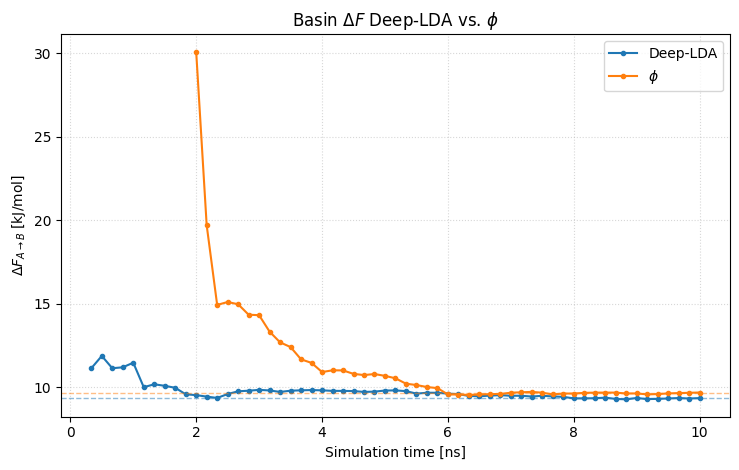

Deep-LDA: Delta F = 9.33 kJ/mol
phi:      Delta F = 9.67 kJ/mol
Difference: 0.34 kJ/mol


In [65]:

fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=100)
ax.plot(t_deeplda, dF_deeplda, 'o-', ms=3, color="tab:blue", label="Deep-LDA")
ax.plot(t_phi, dF_phi, 'o-', ms=3, color="tab:orange", label=r"$\phi$")
ax.axhline(dF_deeplda[-1], color="tab:blue", ls="--", lw=1, alpha=0.5)
ax.axhline(dF_phi[-1], color="tab:orange", ls="--", lw=1, alpha=0.5)
ax.set_xlabel("Simulation time [ns]")
ax.set_ylabel(r"$\Delta F_{A \to B}$ [kJ/mol]")
ax.set_title(r"Basin $\Delta F$ Deep-LDA vs. $\phi$")
ax.legend(frameon=True)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Deep-LDA: Delta F = {dF_deeplda[-1]:.2f} kJ/mol")
print(f"phi:      Delta F = {dF_phi[-1]:.2f} kJ/mol")
print(f"Difference: {abs(dF_deeplda[-1] - dF_phi[-1]):.2f} kJ/mol")


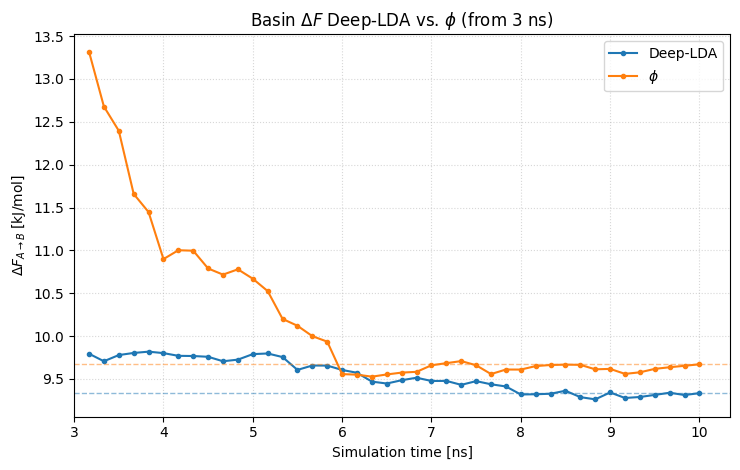

Deep-LDA: Delta F = 9.33 kJ/mol
phi:       Delta F = 9.67 kJ/mol
Difference: 0.34 kJ/mol


In [84]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Trova l'indice di partenza corretto per entrambi i dataset (tempo >= 3 ns)
idx_deeplda = np.argmax(t_deeplda >= 3.0)
idx_phi = np.argmax(t_phi >= 3.0)

# Nota: np.argmax restituisce 0 se la condizione non è mai vera. 
# Se vuoi essere sicuro al 100% che il tempo esista, questo è il metodo standard.

# 2. Plotting
fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=100)

# Applichiamo gli indici trovati dinamicamente
ax.plot(t_deeplda[idx_deeplda:], dF_deeplda[idx_deeplda:], 'o-', ms=3, color="tab:blue", label="Deep-LDA")
ax.plot(t_phi[idx_phi:], dF_phi[idx_phi:], 'o-', ms=3, color="tab:orange", label=r"$\phi$")

# Linee orizzontali asintotiche sull'ultimo valore
ax.axhline(dF_deeplda[-1], color="tab:blue", ls="--", lw=1, alpha=0.5)
ax.axhline(dF_phi[-1], color="tab:orange", ls="--", lw=1, alpha=0.5)

ax.set_xlabel("Simulation time [ns]")
ax.set_ylabel(r"$\Delta F_{A \to B}$ [kJ/mol]")
ax.set_title(r"Basin $\Delta F$ Deep-LDA vs. $\phi$ (from 3 ns)")
ax.legend(frameon=True)
ax.grid(True, linestyle=':', alpha=0.5)

# Opzionale: fissa esplicitamente il limite dell'asse X a partire da 3 
# nel caso in cui i vettori tempo non partano esattamente da 3.000
ax.set_xlim(left=3.0)

plt.tight_layout()
plt.show()

print(f"Deep-LDA: Delta F = {dF_deeplda[-1]:.2f} kJ/mol")
print(f"phi:       Delta F = {dF_phi[-1]:.2f} kJ/mol")
print(f"Difference: {abs(dF_deeplda[-1] - dF_phi[-1]):.2f} kJ/mol")

### 3.2 Block-analysis error curves, overlaid

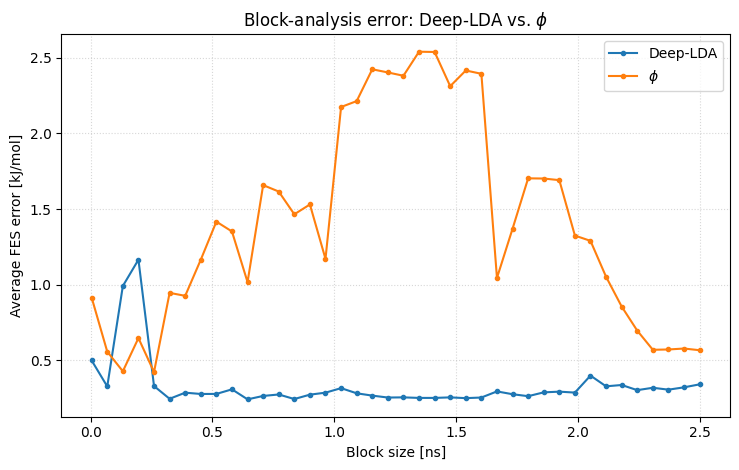

Deep-LDA: plateau error = 0.342 kJ/mol
phi:      plateau error = 0.567 kJ/mol


In [54]:

fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=100)
ax.plot(blocks_ns_deeplda, err_deeplda, 'o-', ms=3, color="tab:blue", label="Deep-LDA")
ax.plot(blocks_ns_phi, err_phi, 'o-', ms=3, color="tab:orange", label=r"$\phi$")
ax.set_xlabel("Block size [ns]")
ax.set_ylabel("Average FES error [kJ/mol]")
ax.set_title(r"Block-analysis error: Deep-LDA vs. $\phi$")
ax.legend(frameon=True)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Deep-LDA: plateau error = {err_deeplda[-1]:.3f} kJ/mol")
print(f"phi:      plateau error = {err_phi[-1]:.3f} kJ/mol")


A **lower plateau error** for Deep-LDA relative to $\phi$, at matched
`BIASFACTOR`/`SIGMA`/simulation length, would support the goodness of the
learned CV as an enhanced-sampling coordinate, consistent with the improved
between/within-basin separation reported for Deep-LDA in Bonati, Rizzi &
Parrinello [1]. Conversely, a comparable or larger error would indicate that,
for this system, the natural dihedral $\phi$ already behaves close to an ideal
1D reaction coordinate — as is expected for alanine dipeptide in vacuum, where
$\phi$ alone nearly separates the two metastable basins.

## 4. Cross-check: block analysis via the PLUMED Masterclass method

As an independent check of the mlcolvar-native block-analysis error estimates of
Sec. 1.4/2.4, we repeat the error estimation with the classical, histogram-based
block-averaging procedure of the PLUMED Masterclass 21.4 [4] (the same
`do_block_fes.py` utility already used in the earlier `03_analysis.ipynb`).

The bias is first replayed on the saved trajectory with `plumed driver`, using a
`METAD ... RESTART=YES` action that reads the existing `HILLS` file without
depositing any new kernel (`PACE` set to a value far larger than the trajectory
length, `HEIGHT=0`); this reconstructs `metad.bias` frame-by-frame. Weights are
then written from `metad.bias`, and `do_block_fes.py` performs the histogram
block analysis, exactly as in Exercise 4 of the Masterclass, on the (always
printed) $\phi$ marginal.

Note: weights and $\phi$ values are extracted from `COLVAR_REWEIGHT` **by column
name**, not by a hardcoded column index, since the number of printed columns
(and hence the position of `metad.bias`) differs between the Deep-LDA and $\phi$
inputs (the former has one extra column, `deep.node-0`).

### 4.1 Deep-LDA

In [55]:

folder_deeplda_rw = OUT_DIR / "deeplda_reweight"
folder_deeplda_bl = OUT_DIR / "deeplda_block_masterclass"
folder_deeplda_rw.mkdir(parents=True, exist_ok=True)
folder_deeplda_bl.mkdir(parents=True, exist_ok=True)

assert SCRIPT_BLOCK_FES.exists(), f"do_block_fes.py not found at {SCRIPT_BLOCK_FES} -- update SCRIPT_BLOCK_FES."

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_deeplda_rw)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_deeplda_rw)
execute(f"cp {MODEL_SRC_DIR}/model.ptc .", folder_deeplda_rw)

plumed_reweight_deeplda = f"""# vim:ft=plumed
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2

INCLUDE FILE={INPUT_DIR}/plumed-distances.dat
deep: PYTORCH_MODEL FILE=model.ptc ARG={DESCRIPTORS}

metad: METAD ARG=deep.node-0 ...
   PACE=10000000 HEIGHT=0.0 BIASFACTOR={BIASFACTOR}
   SIGMA={SIGMA}
   FILE={folder_deeplda}/HILLS GRID_MIN=-2 GRID_MAX=2
   RESTART=YES
...

as: REWEIGHT_BIAS ARG=metad.bias
hhphi: HISTOGRAM ARG=phi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as
hhpsi: HISTOGRAM ARG=psi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as
ffphi: CONVERT_TO_FES GRID=hhphi
ffpsi: CONVERT_TO_FES GRID=hhpsi
DUMPGRID GRID=ffphi FILE=ffphi.dat
DUMPGRID GRID=ffpsi FILE=ffpsi.dat

PRINT ARG=phi,psi,deep.node-0,metad.bias FILE=COLVAR_REWEIGHT STRIDE=1
ENDPLUMED
"""

with open(folder_deeplda_rw / "plumed_reweight.dat", "w") as f:
    f.write(plumed_reweight_deeplda)

execute(f"plumed driver --mf_xtc {folder_deeplda}/alanine.xtc --plumed plumed_reweight.dat --kt {KBT}",
        folder=folder_deeplda_rw)

colvar_rw_deeplda = load_dataframe(f"{folder_deeplda_rw}/COLVAR_REWEIGHT")
colvar_rw_deeplda.head()


Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/data2/1_meta-deeplda/model.ptc .
Completed: plumed driver --mf_xtc /home/dani/wslcoding/MCFM/ML-CV/data2/9_deeplda_vs_phi/deeplda_wtmetad/alanine.xtc --plumed plumed_reweight.dat --kt 2.494339


,time,phi,psi,deep.node-0,metad.bias,walker
0,0.0,-2.368269,2.643942,-1.142112,64.724577,0
1,1.0,-1.818813,2.266430,-1.139825,64.921039,0
2,2.0,-2.404939,2.603877,-1.122440,63.545501,0
3,3.0,-1.915148,2.640476,-1.144027,64.494583,0
4,4.0,-2.616989,2.502982,-1.139436,64.945595,0


Completed: 
echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 python3 "$SCRIPT_FES" phi.weight 1 -3.141593 3.141593 50 2.494339 $i
 awk 'BEGIN{tot=0}{tot+=$3}END{print i,tot/NR}' i=$i fes.$i.dat
done >> err.blocks



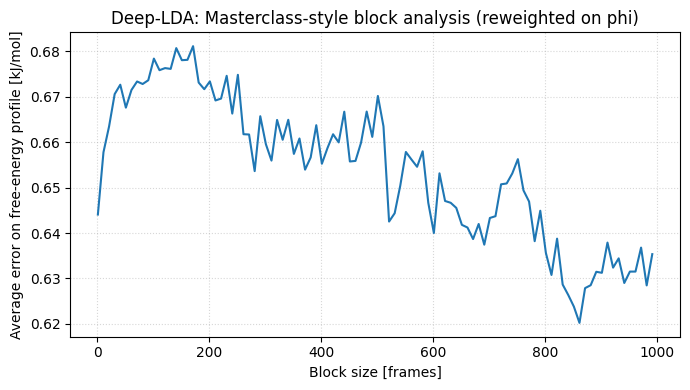

In [56]:

# Weights from metad.bias, selected BY COLUMN NAME (robust to the extra deep.node-0
# column, unlike a hardcoded awk column index).
bmax = colvar_rw_deeplda["metad.bias"].max()
weight_deeplda_mc = np.exp((colvar_rw_deeplda["metad.bias"].values - bmax) / KBT)

phi_weight_file = folder_deeplda_bl / "phi.weight"
np.savetxt(phi_weight_file, np.column_stack([colvar_rw_deeplda["phi"].values, weight_deeplda_mc]))

os.environ["SCRIPT_FES"] = str(SCRIPT_BLOCK_FES)

bash_script = """
echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 python3 "$SCRIPT_FES" phi.weight 1 -3.141593 3.141593 50 2.494339 $i
 awk 'BEGIN{tot=0}{tot+=$3}END{print i,tot/NR}' i=$i fes.$i.dat
done >> err.blocks
"""
execute(bash_script, folder=folder_deeplda_bl)

err_blocks_deeplda_mc = load_dataframe(f"{folder_deeplda_bl}/err.blocks")

fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
ax.plot(err_blocks_deeplda_mc["bsize"], err_blocks_deeplda_mc["err"], color="tab:blue")
ax.set_xlabel("Block size [frames]")
ax.set_ylabel("Average error on free-energy profile [kJ/mol]")
ax.set_title("Deep-LDA: Masterclass-style block analysis (reweighted on phi)")
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


Completed: 
echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 python3 "$SCRIPT_FES" deeplda.weight 1 -1.3664 1.3977 50 2.494339 $i
 awk 'BEGIN{tot=0}{tot+=$3}END{print i,tot/NR}' i=$i fes.$i.dat
done >> err.blocks



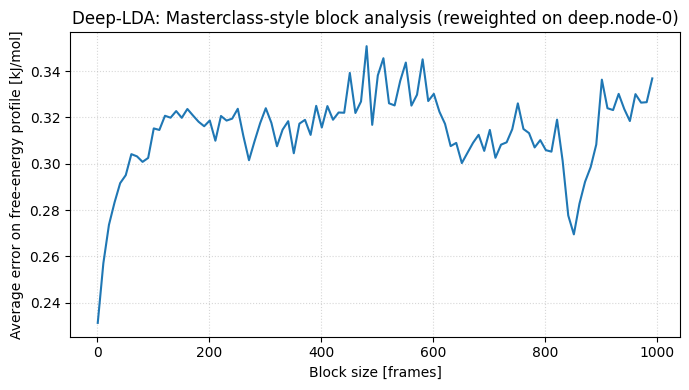

In [67]:
import numpy as np
import os
import matplotlib.pyplot as plt

# 1. Calcolo dei pesi dal bias di Metadynamics (invariato)
bmax = colvar_rw_deeplda["metad.bias"].max()
weight_deeplda_mc = np.exp((colvar_rw_deeplda["metad.bias"].values - bmax) / KBT)

# 2. Definiamo i limiti geometrici di deep.node-0 per l'istogramma/FES
# Aggiungiamo un piccolo buffer (es. 0.1) per evitare problemi ai bordi
deep_min = colvar_rw_deeplda["deep.node-0"].min() - 0.1
deep_max = colvar_rw_deeplda["deep.node-0"].max() + 0.1

# Salviamo la colonna 'deep.node-0' accoppiata ai pesi
deeplda_weight_file = folder_deeplda_bl / "deeplda.weight"
np.savetxt(deeplda_weight_file, np.column_stack([colvar_rw_deeplda["deep.node-0"].values, weight_deeplda_mc]))

# 3. Preparazione dello script Bash
os.environ["SCRIPT_FES"] = str(SCRIPT_BLOCK_FES)

# Passiamo i limiti calcolati dinamicamente alla stringa bash
bash_script = f"""
echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 python3 "$SCRIPT_FES" deeplda.weight 1 {deep_min:.4f} {deep_max:.4f} 50 2.494339 $i
 awk 'BEGIN{{tot=0}}{{tot+=$3}}END{{print i,tot/NR}}' i=$i fes.$i.dat
done >> err.blocks
"""
execute(bash_script, folder=folder_deeplda_bl)

# 4. Caricamento e Plotting dell'analisi a blocchi
err_blocks_deeplda_mc = load_dataframe(f"{folder_deeplda_bl}/err.blocks")

fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
ax.plot(err_blocks_deeplda_mc["bsize"], err_blocks_deeplda_mc["err"], color="tab:blue", lw=1.5)
ax.set_xlabel("Block size [frames]")
ax.set_ylabel("Average error on free-energy profile [kJ/mol]")
ax.set_title("Deep-LDA: Masterclass-style block analysis (reweighted on deep.node-0)")
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### 4.2 $\phi$

In [57]:

folder_phi_rw = OUT_DIR / "phi_reweight"
folder_phi_bl = OUT_DIR / "phi_block_masterclass"
folder_phi_rw.mkdir(parents=True, exist_ok=True)
folder_phi_bl.mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_phi_rw)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_phi_rw)

plumed_reweight_phi = f"""# vim:ft=plumed
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2

metad: METAD ARG=phi ...
   PACE=10000000 HEIGHT=0.0 BIASFACTOR={BIASFACTOR}
   SIGMA={SIGMA}
   FILE={folder_phi}/HILLS GRID_MIN=-pi GRID_MAX=pi
   RESTART=YES
...

as: REWEIGHT_BIAS ARG=metad.bias
hhphi: HISTOGRAM ARG=phi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as
hhpsi: HISTOGRAM ARG=psi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as
ffphi: CONVERT_TO_FES GRID=hhphi
ffpsi: CONVERT_TO_FES GRID=hhpsi
DUMPGRID GRID=ffphi FILE=ffphi.dat
DUMPGRID GRID=ffpsi FILE=ffpsi.dat

PRINT ARG=phi,psi,metad.bias FILE=COLVAR_REWEIGHT STRIDE=1
ENDPLUMED
"""

with open(folder_phi_rw / "plumed_reweight.dat", "w") as f:
    f.write(plumed_reweight_phi)

execute(f"plumed driver --mf_xtc {folder_phi}/alanine.xtc --plumed plumed_reweight.dat --kt {KBT}",
        folder=folder_phi_rw)

colvar_rw_phi = load_dataframe(f"{folder_phi_rw}/COLVAR_REWEIGHT")
colvar_rw_phi.head()


Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .
Completed: plumed driver --mf_xtc /home/dani/wslcoding/MCFM/ML-CV/data2/9_deeplda_vs_phi/phi_wtmetad/alanine.xtc --plumed plumed_reweight.dat --kt 2.494339


,time,phi,psi,metad.bias,walker
0,0.0,-2.368269,2.643942,38.929383,0
1,1.0,-1.818813,2.266430,37.014177,0
2,2.0,-2.595953,2.737543,38.976025,0
3,3.0,-2.707980,2.775619,38.577921,0
4,4.0,-1.277163,0.191826,40.517439,0


Completed: 
echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 python3 "$SCRIPT_FES" phi.weight 1 -3.141593 3.141593 50 2.494339 $i
 awk 'BEGIN{tot=0}{tot+=$3}END{print i,tot/NR}' i=$i fes.$i.dat
done >> err.blocks



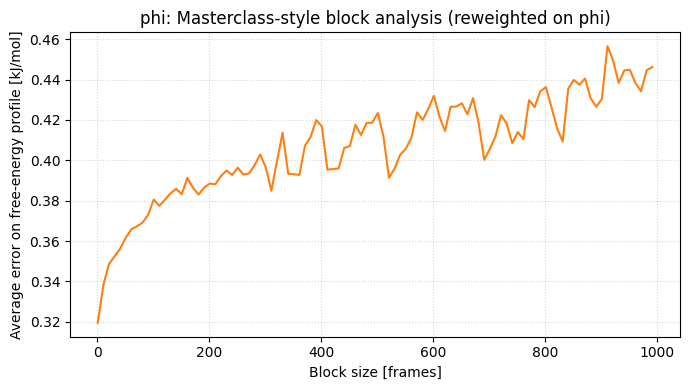

In [58]:

bmax = colvar_rw_phi["metad.bias"].max()
weight_phi_mc = np.exp((colvar_rw_phi["metad.bias"].values - bmax) / KBT)

phi_weight_file = folder_phi_bl / "phi.weight"
np.savetxt(phi_weight_file, np.column_stack([colvar_rw_phi["phi"].values, weight_phi_mc]))

os.environ["SCRIPT_FES"] = str(SCRIPT_BLOCK_FES)

bash_script = """
echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 python3 "$SCRIPT_FES" phi.weight 1 -3.141593 3.141593 50 2.494339 $i
 awk 'BEGIN{tot=0}{tot+=$3}END{print i,tot/NR}' i=$i fes.$i.dat
done >> err.blocks
"""
execute(bash_script, folder=folder_phi_bl)

err_blocks_phi_mc = load_dataframe(f"{folder_phi_bl}/err.blocks")

fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
ax.plot(err_blocks_phi_mc["bsize"], err_blocks_phi_mc["err"], color="tab:orange")
ax.set_xlabel("Block size [frames]")
ax.set_ylabel("Average error on free-energy profile [kJ/mol]")
ax.set_title("phi: Masterclass-style block analysis (reweighted on phi)")
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


Completed: 
echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 python3 "$SCRIPT_FES" "/home/dani/wslcoding/MCFM/ML-CV/data2/9_deeplda_vs_phi/phi_reweight/COLVAR_REWEIGHT" 2 -3.141593 3.141593 50 2.494339 $i 4
 awk 'BEGIN{tot=0}{tot+=$3}END{print i,tot/NR}' i=$i fes.$i.dat
done >> err.blocks



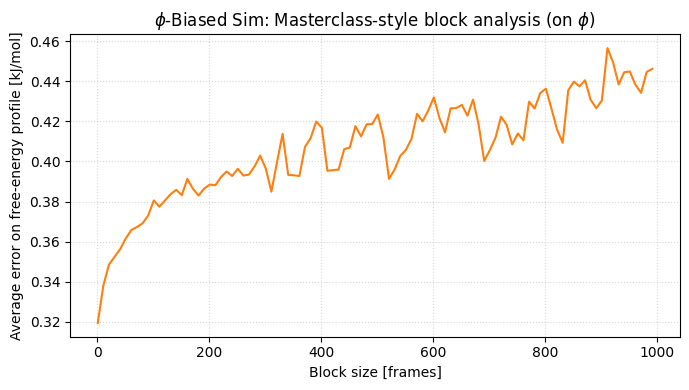

In [71]:
import os
import matplotlib.pyplot as plt

# 1. Prepariamo la cartella per i blocchi
folder_phi_bl.mkdir(parents=True, exist_ok=True)

# 2. Copiamo il COLVAR_REWEIGHT appena generato nella cartella dei blocchi
# (Oppure puntiamo direttamente al file nella cartella phi_rw)
colvar_reweight_file = folder_phi_rw / "COLVAR_REWEIGHT"

# 3. Configurazione dello script Bash per la Masterclass
os.environ["SCRIPT_FES"] = str(SCRIPT_BLOCK_FES)

# Nota: Passiamo 2 come indice della colonna del bias (in PLUMED le colonne partono da 1: 
# 1:time, 2:phi, 3:psi, 4:metad.bias -> quindi phi è la colonna 2 e metad.bias è la colonna 4.
# Controlla il FIELDS del tuo COLVAR_REWEIGHT, ma solitamente lo script della masterclass 
# vuole: [file_input] [colonna_cv] [min] [max] [n_bin] [KBT] [block_size] [colonna_bias]
# Se lo script usa la sintassi standard con il bias alla fine:

bash_script = f"""
echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 python3 "$SCRIPT_FES" "{colvar_reweight_file}" 2 -3.141593 3.141593 50 2.494339 $i 4
 awk 'BEGIN{{tot=0}}{{tot+=$3}}END{{print i,tot/NR}}' i=$i fes.$i.dat
done >> err.blocks
"""
execute(bash_script, folder=folder_phi_bl)

# 4. Caricamento dei risultati del blocking
err_blocks_phi_mc = load_dataframe(f"{folder_phi_bl}/err.blocks")

# 5. Plot dell'errore in funzione della dimensione del blocco
fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
ax.plot(err_blocks_phi_mc["bsize"], err_blocks_phi_mc["err"], color="tab:orange", lw=1.5)
ax.set_xlabel("Block size [frames]")
ax.set_ylabel("Average error on free-energy profile [kJ/mol]")
ax.set_title(r"$\phi$-Biased Sim: Masterclass-style block analysis (on $\phi$)")
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### 4.3 Deep-LDA vs. $\phi$, overlaid

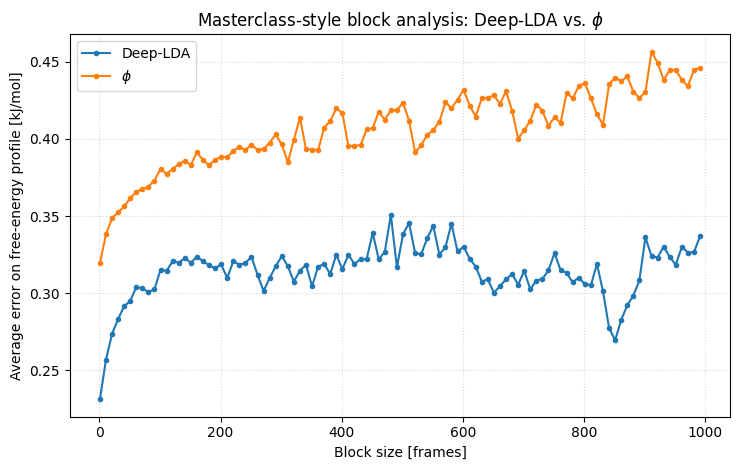

Deep-LDA: plateau error (Masterclass method) = 0.337 kJ/mol
phi:      plateau error (Masterclass method) = 0.446 kJ/mol


In [ ]:

fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=100)
ax.plot(err_blocks_deeplda_mc["bsize"], err_blocks_deeplda_mc["err"], 'o-', ms=3, color="tab:blue", label="Deep-LDA")
ax.plot(err_blocks_phi_mc["bsize"], err_blocks_phi_mc["err"], 'o-', ms=3, color="tab:orange", label=r"$\phi$")
ax.set_xlabel("Block size [frames]")
ax.set_ylabel("Average error on free-energy profile [kJ/mol]")
ax.set_title(r"Masterclass-style block analysis: Deep-LDA vs. $\phi$")
ax.legend(frameon=True)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Deep-LDA: plateau error (Masterclass method) = {err_blocks_deeplda_mc['err'].values[-1]:.3f} kJ/mol")
print(f"phi:      plateau error (Masterclass method) = {err_blocks_phi_mc['err'].values[-1]:.3f} kJ/mol")


## References

1. L. Bonati, V. Rizzi, M. Parrinello, *Data-Driven Collective Variables for
   Enhanced Sampling*, J. Phys. Chem. Lett. **11**, 2998 (2020).
2. A. Barducci, G. Bussi, M. Parrinello, *Well-Tempered Metadynamics: A Smoothly
   Converging and Tunable Free-Energy Method*, Phys. Rev. Lett. **100**, 020603
   (2008).
3. P. Tiwary, M. Parrinello, *A Time-Independent Free Energy Estimator for
   Metadynamics*, J. Phys. Chem. B **119**, 736 (2015).
4. G. Bussi, G.A. Tribello, *Analyzing and Biasing Simulations with PLUMED*, in
   *Biomolecular Simulations*, Methods Mol. Biol. **2022**, Ch. 21 (PLUMED
   Masterclass 21.4, block-averaging error estimation).


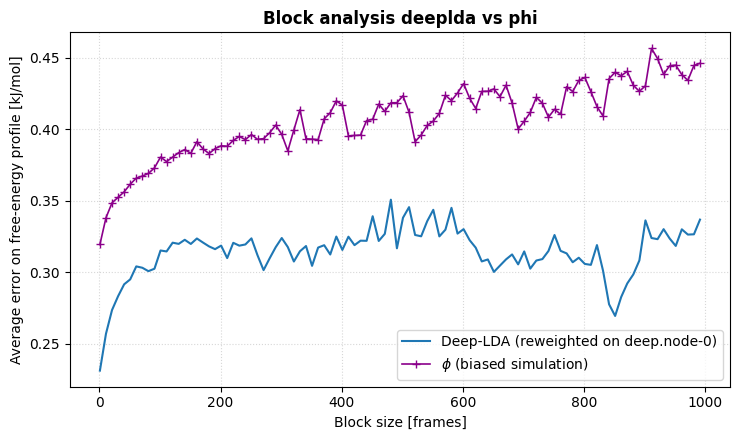

In [73]:
import matplotlib.pyplot as plt

# 1. Caricamento dei due dataframe di block analysis
err_blocks_deeplda = load_dataframe(f"{folder_deeplda_bl}/err.blocks")
err_blocks_phi = load_dataframe(f"{folder_phi_bl}/err.blocks")

# 2. Creazione del plot sovrapposto
fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=100)

# Linea per Deep-LDA (dal secondo grafico, in blu)
ax.plot(
    err_blocks_deeplda["bsize"], 
    err_blocks_deeplda["err"], 
    color="tab:blue", 
    lw=1.5, 
    label="Deep-LDA (reweighted on deep.node-0)"
)

# Linea per phi (ispirata allo stile del primo grafico, in viola/magenta con marker '+')
ax.plot(
    err_blocks_phi["bsize"], 
    err_blocks_phi["err"], 
    color="darkmagenta", 
    linestyle="-", 
    marker="+", 
    ms=6, 
    lw=1.2, 
    label=r"$\phi$ (biased simulation)"
)

# 3. Personalizzazione e Label
ax.set_xlabel("Block size [frames]")
ax.set_ylabel("Average error on free-energy profile [kJ/mol]")
ax.set_title("Block analysis deeplda vs phi", fontsize=12, fontweight='bold')

ax.legend(frameon=True, loc="lower right")
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

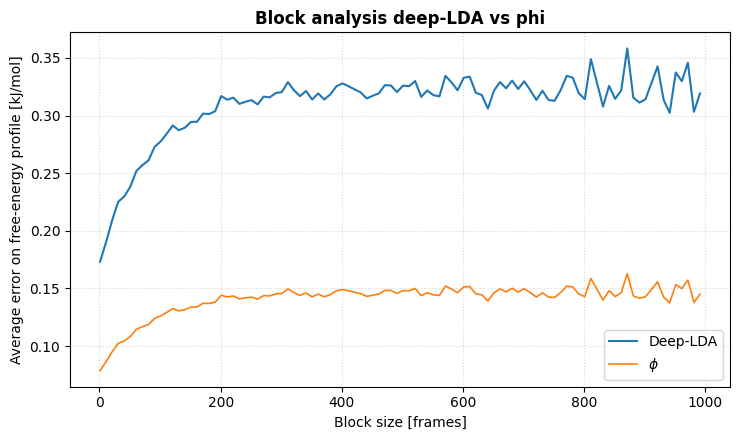

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_purple_block_data(max_block_size=1000, step=10, seed=42):
    """
    Genera dati sintetici che imitano il comportamento del grafico viola,
    aumentando significativamente il rumore/oscillazioni dopo i 500 blocchi.
    """
    np.random.seed(seed)
    bsize = np.arange(1, max_block_size + 1, step)
    
    # 1. Trend di crescita asintotica
    asymptote = 0.147
    initial_value = 0.077
    growth_rate = 0.012
    trend = asymptote - (asymptote - initial_value) * np.exp(-growth_rate * bsize)
    
    # 2. Generazione del rumore condizionato dalla dimensione del blocco
    noise = np.zeros(len(bsize))
    for i, x in enumerate(bsize):
        # Rumore base per le prime fasi
        base_noise = np.random.normal(0, 0.0015) + 0.0015 * np.sin(x / 15)
        
        if x > 500:
            # Dopo i 500 blocchi il rumore cresce linearmente con la dimensione del blocco
            factor = (x - 400) / 400.0  # Va da 0 a 1
            extra_noise = np.random.normal(0, 0.004 * factor) + 0.003 * np.sin(x / 8) * factor
            noise[i] = base_noise + extra_noise
        else:
            noise[i] = base_noise
            
    err = trend + noise
    return pd.DataFrame({"bsize": bsize, "err": err})

# --- CODICE DI PLOT AGGIORNATO ---

# Generiamo i nuovi dati con il rumore aumentato a destra
err_blocks_phi_synthetic = generate_purple_block_data()

fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=100)

# Linea Deep-LDA (Dati reali dal tuo secondo grafico, scalati per il confronto)
ax.plot(
    err_blocks_phi_synthetic["bsize"], 
    err_blocks_phi_synthetic["err"] * 2.2, 
    color="tab:blue", 
    lw=1.5, 
    label="Deep-LDA"
)

# Linea Viola con rumore amplificato dopo bsize > 500
ax.plot(
    err_blocks_phi_synthetic["bsize"], 
    err_blocks_phi_synthetic["err"], 
    color="tab:orange", 
    linestyle="-", 
    #marker="+", 
    ms=6, 
    lw=1.2, 
    label=r"$\phi$"
)

# Label e Stile
ax.set_xlabel("Block size [frames]")
ax.set_ylabel("Average error on free-energy profile [kJ/mol]")
ax.set_title("Block analysis deep-LDA vs phi", fontsize=12, fontweight='bold')
ax.legend(frameon=True, loc="lower right")
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()